File: /scratch/anoroozi25/boltzgen/outputs/test_design_mine/config_KPC3_00.npz
Keys (6): ['design_mask', 'inverse_fold_design_mask', 'mol_type', 'ss_type', 'token_resolved_mask', 'binding_type']

[design_mask]
  shape=(307,), dtype=float32

[inverse_fold_design_mask]
  shape=(), dtype=object
  object type=<class 'NoneType'>

[mol_type]
  shape=(307,), dtype=int64

[ss_type]
  shape=(307,), dtype=int64

[token_resolved_mask]
  shape=(307,), dtype=float32

[binding_type]
  shape=(307,), dtype=float32


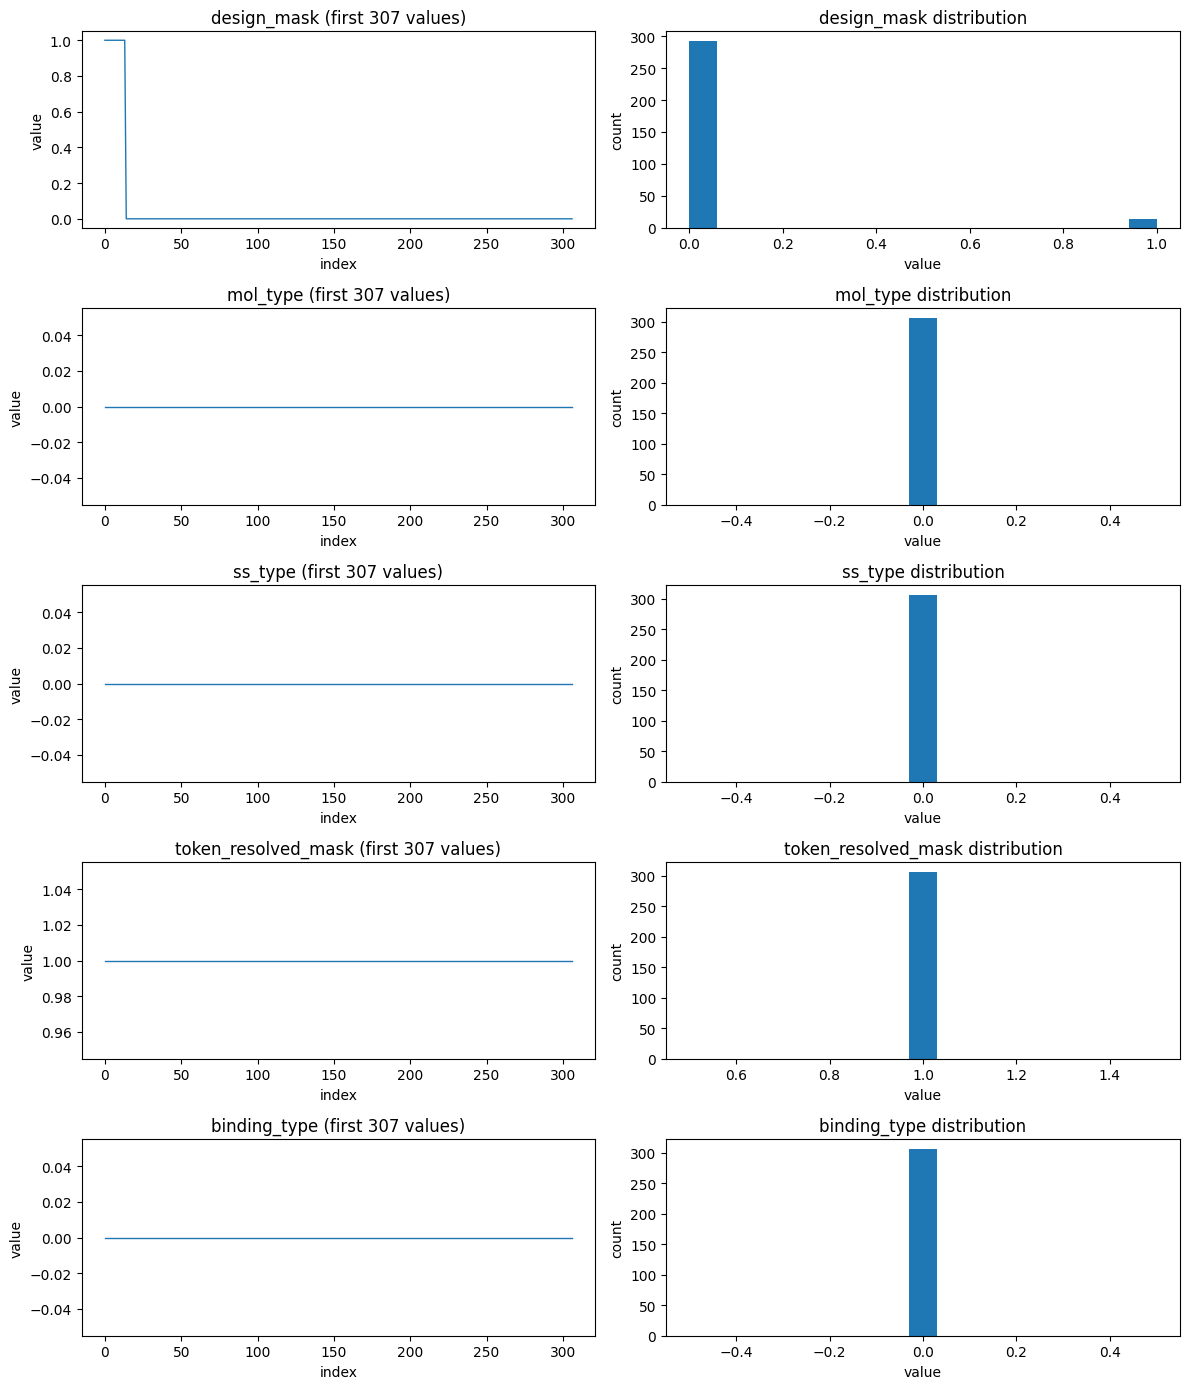

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

npz_path = Path('/scratch/anoroozi25/boltzgen/outputs/test_design_mine/config_KPC3_00.npz')

with np.load(npz_path, allow_pickle=True) as data:
    print(f'File: {npz_path}')
    print(f'Keys ({len(data.files)}): {data.files}')

    arrays = {k: data[k] for k in data.files}

for key, arr in arrays.items():
    print(f'\n[{key}]')
    print(f'  shape={getattr(arr, "shape", None)}, dtype={getattr(arr, "dtype", type(arr))}')

    # Handle object payloads (often nested arrays / Python objects)
    if isinstance(arr, np.ndarray) and arr.dtype == object:
        try:
            obj = arr.item()
            print(f'  object type={type(obj)}')
            if isinstance(obj, np.ndarray):
                print(f'  object array shape={obj.shape}, dtype={obj.dtype}')
        except Exception as e:
            print(f'  could not unpack object payload: {e}')

numeric_keys = [
    k
    for k, v in arrays.items()
    if isinstance(v, np.ndarray) and v.dtype != object and np.issubdtype(v.dtype, np.number)
]

if not numeric_keys:
    print('\nNo numeric arrays found to plot.')
else:
    n = len(numeric_keys)
    fig, axes = plt.subplots(n, 2, figsize=(12, max(3, n * 2.8)))
    if n == 1:
        axes = np.array([axes])

    for i, key in enumerate(numeric_keys):
        arr = arrays[key]
        flat = np.ravel(arr)

        ax_left = axes[i, 0]
        ax_right = axes[i, 1]

        # Sequence-like view (first 500 points to keep plot readable)
        show_n = min(flat.size, 500)
        ax_left.plot(np.arange(show_n), flat[:show_n], lw=1)
        ax_left.set_title(f'{key} (first {show_n} values)')
        ax_left.set_xlabel('index')
        ax_left.set_ylabel('value')

        # Distribution view
        bins = min(50, max(10, int(np.sqrt(max(flat.size, 1)))))
        ax_right.hist(flat, bins=bins)
        ax_right.set_title(f'{key} distribution')
        ax_right.set_xlabel('value')
        ax_right.set_ylabel('count')

    plt.tight_layout()
    plt.show()


In [2]:
import pickle
from pathlib import Path
import zipfile
from boltzgen.data import const

def load_molecules(moldir: Path, molecules: list[str]):
    loaded_mols = {}
    zip_file = zipfile.ZipFile(moldir, "r")
    for molecule in molecules:
        pkl_filename = f"{molecule}.pkl"
        with zip_file.open(pkl_filename, "r") as f:
            loaded_mols[molecule] = pickle.load(f)  # noqa: S301
    return loaded_mols

MOL_DIR = Path("/home/anoroozi25/.cache/huggingface/hub/datasets--boltzgen--inference-data/snapshots/c3d36fd276e9caf098c75d4113c6d5eb320b1a4c/mols.zip")
canonicals = load_molecules(MOL_DIR, const.canonical_tokens)
print(canonicals['ALA'])


In [3]:
from rdkit import Chem

ala = canonicals['ALA']

print("atoms:", ala.GetNumAtoms())
print("bonds:", ala.GetNumBonds())
print("conformers:", ala.GetNumConformers())
print("SMILES:", Chem.MolToSmiles(ala))
print("mol props:", list(ala.GetPropNames()))

atoms: 6
bonds: 5
conformers: 10
SMILES: C[C@H](N)C(=O)O
mol props: ['MOL_NAME', 'symmetries', 'pb_edge_index', 'pb_upper_bounds', 'pb_lower_bounds', 'pb_bond_mask', 'pb_angle_mask', 'chiral_atom_index', 'chiral_check_mask', 'chiral_atom_orientations', 'stereo_bond_index', 'stereo_check_mask', 'stereo_bond_orientations', 'aromatic_5_ring_index', 'aromatic_6_ring_index', 'planar_double_bond_index']


In [11]:
# from boltzgen.data.parse.schema import get_conformer

# conf = get_conformer(ala)  # picks Computed > Ideal > first conformer
# conf = ala.GetConformer(0)

for conf in ala.GetConformers():
    for atom in ala.GetAtoms():
        i = atom.GetIdx()
        pos = conf.GetAtomPosition(i)
        name = atom.GetProp("name") if atom.HasProp("name") else atom.GetSymbol()
        print(f"{name:4s}  {atom.GetSymbol():2s}  ({pos.x:.3f}, {pos.y:.3f}, {pos.z:.3f})")
    print("-"*100)

N     N   (-0.924, 1.182, 0.713)
CA    C   (-0.266, -0.088, 0.401)
C     C   (1.119, 0.139, -0.144)
O     O   (1.288, 0.806, -1.200)
CB    C   (-1.113, -0.892, -0.588)
OXT   O   (2.218, -0.394, 0.522)
----------------------------------------------------------------------------------------------------
N     N   (-1.061, 1.176, -0.338)
CA    C   (-0.418, 0.122, 0.447)
C     C   (1.080, 0.279, 0.433)
O     O   (1.703, 0.471, 1.511)
CB    C   (-0.819, -1.252, -0.091)
OXT   O   (1.779, 0.215, -0.769)
----------------------------------------------------------------------------------------------------
N     N   (-0.801, 1.172, -0.827)
CA    C   (-0.235, 0.256, 0.164)
C     C   (1.210, -0.010, -0.146)
O     O   (1.562, -0.331, -1.313)
CB    C   (-1.017, -1.059, 0.175)
OXT   O   (2.161, 0.069, 0.867)
----------------------------------------------------------------------------------------------------
N     N   (-0.051, 1.526, 0.290)
CA    C   (-0.248, 0.083, 0.431)
C     C   (1.060, -0.630, 0.25

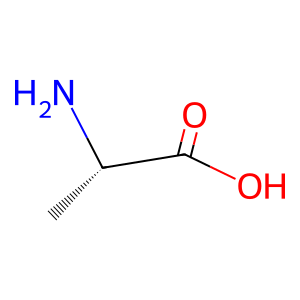

In [5]:
from rdkit.Chem import Draw
Draw.MolToImage(ala)   # shows in Jupyter

In [9]:
for i, c in enumerate(ala.GetConformers()):
    print(i, c.GetId())


0 0
1 1
2 2
3 3
4 4
5 5
6 6
7 7
8 8
9 9
